In [24]:

from pathlib import Path
import pandas as pd
import json
import numpy as np
import pickle

import sys
sys.path.append('../../code/7_GEM_reconstruction')

from matplotlib import pyplot as plt
import scipy.stats as st


import sys
sys.path.append('../../code/6_CRM')
from CRM import CRM
from CRM_utils import make_D, numerical_error, has_converged, make_C



In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [26]:
param_fn = '../../data/8_FBA/CRM_parameters.pkl'


In [27]:
with open(param_fn, 'rb') as f:
    model_data = pickle.load(f)

In [29]:
species = ['At', 'Ct', 'Ml', 'Oa']

In [30]:
model_data['At']['energy_dict']

{'R_EX_14glucan_e': 0.6231947360136152,
 'R_EX_23camp_e': 0.1309882467982767,
 'R_EX_23cump_e': 0.12466702958447662,
 'R_EX_25dkglcn_e': 0.07856526603941516,
 'R_EX_2pglyc_e': 0.021367295374528958,
 'R_EX_3amp_e': 0.13111771682781936,
 'R_EX_3cmp_e': 0.12579620753168352,
 'R_EX_3mb_e': 0.08897441596890404,
 'R_EX_3ump_e': 0.1247871471978293,
 'R_EX_4abut_e': 0.06973227573514656,
 'R_EX_4hoxpac_e': 0.10510294260944136,
 'R_EX_4hpro_LT_e': 0.08233671594428227,
 'R_EX_6atha_e': 0.03794996514675211,
 'R_EX_LalaDgluMdapDala_e': 0.26703234808424137,
 'R_EX_LalaLglu_e': 0.12026201808629694,
 'R_EX_R_3hphpa_e': 0.075899930293504,
 'R_EX_R_3hphxa_e': 0.20269229132372402,
 'R_EX_R_3hpocta_e': 0.25072363997863045,
 'R_EX_R_3hppta_e': 0.03794996514674917,
 'R_EX_ac_e': 0.025936967441210823,
 'R_EX_acald_e': 0.03488523000939442,
 'R_EX_acgam_e': 0.1329312082769586,
 'R_EX_acmana_e': 0.13293120827695848,
 'R_EX_acnam_e': 0.17317868807940884,
 'R_EX_acon_C_e': 0.07579595188602861,
 'R_EX_actn__R_e': 

In [120]:
def define_auxotrophy_arr(aux_dict, species, n_cs, exchanges):
    arr = np.zeros((len(species),n_cs))
    
    j_thm = np.where(np.array(exchanges) == 'R_EX_thm_e')[0][0]
    j_btn = np.where(np.array(exchanges) == 'R_EX_btn_e')[0][0]
    j_cys = np.where(np.array(exchanges) == 'R_EX_cys__L_e')[0][0]
    
    oa_i = np.where(np.array(species) == 'Oa')[0][0]
    ml_i = np.where(np.array(species) == 'Ml')[0][0]

    arr[oa_i, j_thm] = 1e4# np.abs(aux_dict['R_EX_thmpp_e'])
    
    arr[ml_i, j_btn] = np.abs(aux_dict['R_EX_btn_e'])
    arr[ml_i, j_cys] = np.abs(aux_dict['R_EX_cys__L_e'])
    arr[ml_i, j_thm] = np.abs(aux_dict['R_EX_thmpp_e'])
    
    return arr

def define_exchanges(model_data, intracellular_production, species):
    exchanges = set()

    if intracellular_production:
        production = model_data['all_in_production_exchanges']
    else:
        production = model_data['all_ex_production_exchanges']

    all_growth_exchanges  = model_data['all_growth_exchanges']
    cs_exchanges = model_data['cs_exchanges']
    exchanges = [x for x in all_growth_exchanges if x in production or x in cs_exchanges]
    exchanges += ['R_EX_btn_e', 'R_EX_thm_e']
    return sorted(list(exchanges))

def make_C_w(model_data, exchanges, m, ex_rxn_to_mu, c_fit, l, aux_arr):
    C = np.zeros((len(species), len(exchanges)))
    W = np.zeros((len(species), len(exchanges)))
    for i, name in enumerate(species):
        for j, r_id in enumerate(exchanges):
            if r_id in model_data[name]['growth_exchanges']:
                try:
                    mu = ex_rxn_to_mu[(name, r_id)]
                except KeyError:
                    # print(f'Random C value for {name}: {r_id}')
                    mu = max(0, st.lognorm.rvs(*c_fit[name]))
                
                w = model_data[name]['energy_dict'][r_id]
                if w < 1e-3:
                    cmax = 0
                else:
                    cmax = (mu + m)/(1-l)/w

                C[i,j] = max(cmax, 0)
                W[i,j] = model_data[name]['energy_dict'][r_id]

    # Biotin
    i_btn = np.where(np.array(exchanges) == 'R_EX_btn_e')[0][0]
    C[:, i_btn] = 0
    C[2, i_btn] = 1e-4

    i_thm =  np.where(np.array(exchanges) == 'R_EX_thm_e')[0][0]
    C[:, i_thm] = 0
    C[2, i_thm] = 1e-4
    C[3, i_thm] = 1e-4

    i_cys = np.where(np.array(exchanges) == 'R_EX_cys__L_e')[0][0]
    C[:, i_cys] = 0
    C[2, i_cys] = 1e-2

    
    return C, W


def make_D_from_data(model_data, exchanges, species, intracellular_production, add_noise = False, noise_std = 0.5):
    n_species = len(species)
    n_cs = len(exchanges)

    D = np.zeros((n_species, n_cs, n_cs))

    if add_noise:
        noise = st.norm.rvs(loc=0, scale=noise_std, size=(n_species, n_cs))
    else:
        noise = np.zeros((n_species, n_cs, n_cs))
        

    for i, name in enumerate(species):
        print(f'Processing {name} for D matrix...')
        if intracellular_production:
            log_release = model_data[name]['in_log_release']
        else:
            log_release = model_data[name]['ex_log_release']

        for j, r_id in enumerate(exchanges):
            lr = log_release.get(r_id, np.nan)
            if np.isnan(lr):
                D[i, :, j] = 0  # No release for this exchange
            else:
                D[i, :, j] = 10**(lr+noise[i, j])
    
    for j in range(n_cs):
        D[:, j, j] = 0  # No self-transfer

    # D[D<1e-3] = 0
    
    # Normalize 
    D /= D.sum(axis=2, keepdims=True)
    
    # for i in range(n_species):
    #     D[i, :, :] /= D[i, :, :].sum(axis=0)  # Normalize each species' transfers so that they sum to 1

    # Normalize each species' transfers so that they sum to 1
    # for i in range(n_species):
    #     D[i, :, :] /= D[i, :, :].sum(axis=0)
    
    # D = np.transpose(D, (0, 2, 1))  # Transpose to match the expected shape (N_species, N_cs, N_cs)
    return D

def make_K(aux_arr, n_cs, exchanges):
    K = np.random.lognormal(-3,1.6, (4, n_cs))
    print(K.shape)
    
    i_btn = np.where(np.array(exchanges) == 'R_EX_btn_e')[0][0]
    K[:, i_btn] = np.random.lognormal(np.log(1e-7), 1.6, 4)

    i_thm =  np.where(np.array(exchanges) == 'R_EX_thm_e')[0][0]
    K[:, i_thm] = np.random.lognormal(np.log(1e-5), 1.6, 4)

    i_cys = np.where(np.array(exchanges) == 'R_EX_cys__L_e')[0][0]
    K[:, i_cys] = np.random.lognormal(np.log(1e-4), 1.6, 4)

    return K

# Run

In [92]:
model_data['cs_exchanges']

['R_EX_ac_e',
 'R_EX_glc__D_e',
 'R_EX_cit_e',
 'R_EX_glutar_e',
 'R_EX_glyc_e',
 'R_EX_ins_e',
 'R_EX_ala__L_e',
 'R_EX_glu__L_e',
 'R_EX_his__L_e',
 'R_EX_ile__L_e',
 'R_EX_mal__L_e',
 'R_EX_mnl_e',
 'R_EX_man_e',
 'R_EX_inost_e',
 'R_EX_xyl__D_e',
 'R_EX_rib__D_e']

In [32]:
def remove_small_D(D, aux_arr, small = 1e-3):
    for i in range(aux_arr.shape[0]):
        for j in range(D.shape[1]):
            if aux_arr[i,j] != 0:
                D[i, :, j] = 0
            
    for j in range(D.shape[1]):
        if aux_arr[:, j].sum() == 0:
            dj = D[:,:, j]
            if dj.mean() < small:
                D[:, :, j] = 0
    D /= D.sum(axis=2, keepdims=True)
    return D

In [36]:
(C>0).sum(0)

array([1, 2, 3, 1, 4, 1, 2, 4, 2, 2, 2, 2, 2, 4, 4, 1, 4, 2, 2, 4, 2, 2,
       3, 4, 3, 4, 4, 1, 3, 4, 1, 1, 1, 2, 1, 2, 1, 1, 3, 3, 4, 1, 4, 1,
       4, 4, 4, 2, 2, 2, 4, 1, 3, 1, 2, 3, 4, 1, 2, 2, 1, 4, 1, 4, 4, 2,
       2, 1, 3, 3, 1, 1, 4, 4, 4, 4, 4, 1, 3, 1, 4, 1, 1, 1, 1, 2, 3, 2,
       2, 1, 4, 1, 2, 1, 4, 4, 2, 4, 2, 3, 1, 3, 3, 3, 4, 4, 3, 4, 4, 3,
       3, 3, 2, 2, 3, 3, 4, 2, 2, 2, 2, 1, 3, 1, 1, 2, 1, 2, 4, 3, 2, 1,
       2, 4, 4, 4, 4, 4, 2, 1, 3, 2, 4, 4, 3, 2, 2, 4, 4, 4, 1, 3, 1, 1,
       3, 1, 4, 2, 2, 4, 2, 3])

In [118]:
cs_idx=0

R_EX_xyl__D_e
(4, 162)
Processing At for D matrix...
Processing Ct for D matrix...
Processing Ml for D matrix...
Processing Oa for D matrix...
Processing At for D matrix...
Processing Ct for D matrix...
Processing Ml for D matrix...
Processing Oa for D matrix...
Before trimming:
  C shape: (4, 162)
  D shape: (4, 162, 162)
  K shape: (162, 4)

Resource Analysis:
  Total resources: 162
  Never consumed: 161
  Never produced: 96
  Completely inactive: 95
  Keeping: 67 resources
  Reduction: 58.6%

After trimming:
  C shape: (4, 67)
  D shape: (4, 67, 67)
  K shape: (4, 67)
  Number of exchanges: 67
C:  [[0.     0.     0.    ]
 [0.     0.     0.    ]
 [0.0001 0.01   0.0001]
 [0.     0.     0.0001]]

D: [[1.25350761e-05 1.82566523e-03 3.22476213e-04]
 [2.16942337e-05 1.60467183e-04 7.19526993e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [7.13197517e-05 1.29262422e-04 0.00000000e+00]]
[0.05046837 0.05046837 0.05046837]
C uptake [3.72178139 0.         1.77522914 3.46141304]
0


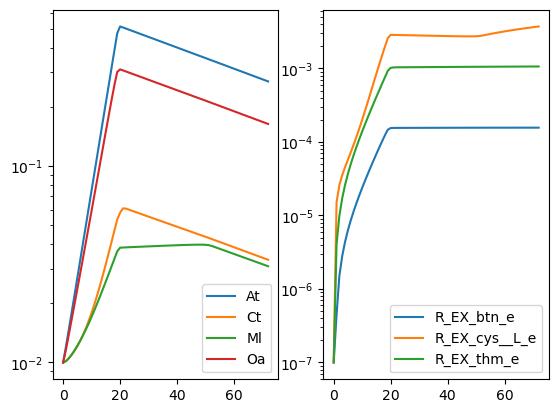

0


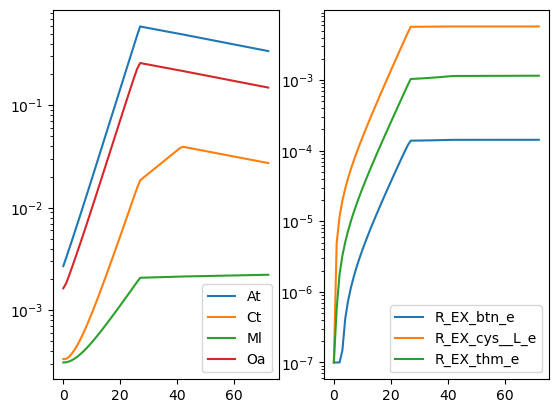

0


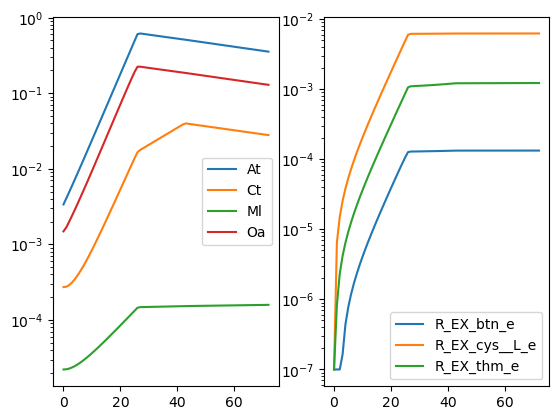

0


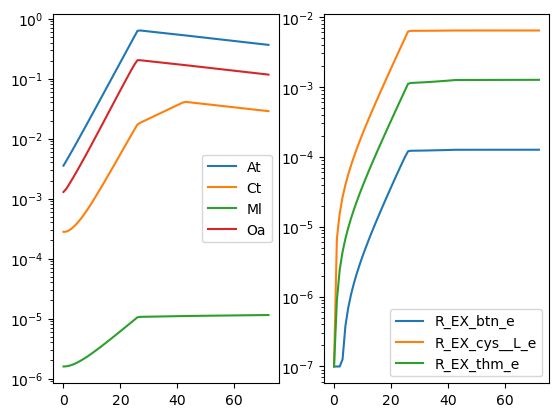

In [133]:
def trim_zero_resources(C, W, D, K, exchanges, R0=None, aux_arr=None):
    """
    Remove resources that are never consumed or produced by any species.
    
    Parameters:
    -----------
    C : array (n_species, n_resources)
        Consumption rates
    W : array (n_species, n_resources)
        Energy content
    D : array (n_species, n_resources, n_resources)
        Leakage matrix
    K : array (n_species, n_resources)  
        Half-saturation constants
    exchanges : list
        Exchange reaction names
    R0 : array (n_resources), optional
        Initial resource concentrations
    aux_arr : array (n_species, n_resources), optional
        Auxotrophy array
    
    Returns:
    --------
    Trimmed versions of all inputs plus mapping indices
    """
    n_species, n_resources = C.shape
    
    
    # Identify active resources
    # consumed = C.sum(axis=0) > 0  # At least one species consumes it
    consumed = (R0 > 0)
    produced = D.sum(axis=(0, 1)) > 0  # At least one species produces it
    active = consumed | produced  # Keep if consumed OR produced

    
    n_removed = (~active).sum()
    n_kept = active.sum()
    
    print(f"Resource Analysis:")
    print(f"  Total resources: {n_resources}")
    print(f"  Never consumed: {(~consumed).sum()}")
    print(f"  Never produced: {(~produced).sum()}")
    print(f"  Completely inactive: {n_removed}")
    print(f"  Keeping: {n_kept} resources")
    print(f"  Reduction: {100*n_removed/n_resources:.1f}%")
    
    # Trim matrices
    C_trim = C[:, active]
    W_trim = W[active]
    K_trim = K[:, active]
    D_trim = D[:, active, :][:, :, active]  # Trim both dimensions
    exchanges_trim = [ex for ex, keep in zip(exchanges, active) if keep]

    D_trim /= D_trim.sum(axis=2, keepdims=True)
    
    result = {
        'C': C_trim,
        'W': W_trim,
        'K': K_trim,
        'D': D_trim,
        'exchanges': exchanges_trim,
        'active_mask': active,
        'active_indices': np.where(active)[0],
        'n_kept': n_kept,
        'n_removed': n_removed
    }
    
    if R0 is not None:
        result['R0'] = R0[active]
    
    if aux_arr is not None:
        result['aux_arr'] = aux_arr[:, active]
        aux_idx = aux_arr[:, active].sum(axis=0) > 0
        W_trim[aux_idx] = W_trim.mean()

        # for i in range(n_species):
            # Set auxotroph idx C to 0
            # aux_idx = aux_arr[i, active] > 0
            # C_trim[i, aux_idx] = 0
        # result['W'] = W_trim
    
    return result
cs_idx +=1
cs = model_data['cs_exchanges'][cs_idx]

initial_abundance = 1e-2
m = 0.0125
l = 0.2


intracellular_production = True
ex_rxn_to_mu = model_data['ex_rxn_to_mu']
c_fit = model_data['c_fit']
exchanges = define_exchanges(model_data, intracellular_production, species)
n_cs = len(exchanges)
print(cs)
k = np.where(np.array(exchanges)==cs)[0][0]

aux_arr = define_auxotrophy_arr(model_data['aux_yield_dict'], species, n_cs, exchanges)
C, W = make_C_w(model_data, exchanges, m, ex_rxn_to_mu, c_fit, l, aux_arr)
K = make_K(aux_arr, n_cs, exchanges)


W = W.mean(axis=0)
dt = 0.1
method = 'LSODA'
initial_c_conc = 10
new_data = []
N0 = np.ones(4) * initial_abundance
# dilution_rate = 0.1
g = 1

D = make_D_from_data(model_data, exchanges, species, intracellular_production, add_noise = False, noise_std = 0.5)
Dr = make_D(4, n_cs)


# Apply trimming
D = make_D_from_data(model_data, exchanges, species, intracellular_production, add_noise = True, noise_std = 0.5)


D = remove_small_D(D, aux_arr, small=1e-3)
print("Before trimming:")
print(f"  C shape: {C.shape}")
print(f"  D shape: {D.shape}")
print(f"  K shape: {K.T.shape}")
print()

R0 = np.zeros(n_cs)
R0[k] = 15


trim_result = trim_zero_resources(C, W, D, K, exchanges, aux_arr=aux_arr, R0=R0)

C_trim = trim_result['C']
W_trim = trim_result['W']
K_trim = trim_result['K']
D_trim = trim_result['D']
exchanges_trim = trim_result['exchanges']
aux_arr_trim = trim_result['aux_arr']
n_cs_trim = C_trim.shape[1]
R0_trim = trim_result['R0']

print()
print("After trimming:")
print(f"  C shape: {C_trim.shape}")
print(f"  D shape: {D_trim.shape}")
print(f"  K shape: {K_trim.shape}")
print(f"  Number of exchanges: {len(exchanges_trim)}")
print('C: ', C_trim[:, aux_arr_trim.sum(0)>0])
print()
print('D:', D_trim[:, 0, aux_arr_trim.sum(0)>0])
print(W_trim[aux_arr_trim.sum(0)>0])
print('C uptake', C[:, k])



method = 'LSODA'
# R0[2] = 15
# l = 0.1

# c = CRM(4, n_cs, C = C, D=Dr, dilution_rate=1e-2, l=l, K=K.T, g=1, w = W, m = m, atol = 1e-10, rtol = 1e-8)
c = CRM(4, n_cs_trim, C = C_trim, D = D_trim, dilution_rate=0, l=l, K=K_trim, g=1, w = W_trim, m = m, atol = 1e-10, rtol = 1e-8)
# sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
c.auxo_arr = aux_arr_trim
for i in range(4):
    if i == 0:
        N = N0
    else:
        N = c.N[-1, :]/100
    c.R_in = None
    print(c.dilution_rate)
    sol = c.run_log(72, N.copy(), R0_trim.copy(), dt=1, method=method, max_calls=1e5)

    fig, (ax1, ax2) = plt.subplots(1,2)
    for i in range(4):
        ax1.semilogy(c.N[:, i], label = species[i])
    ax1.legend()
    
    aux_idxs = np.where(np.array(aux_arr_trim.sum(0)>0))[0]
    for idx in aux_idxs:
        ax2.semilogy(c.R[:, idx], label = exchanges_trim[idx])
    ax2.legend()

    plt.show()
    # plt.semilogy(c.R[:, aux_idxs])

In [56]:
aux_idxs


array([17, 21, 61])

In [52]:
exchanges_trim[np.where(c.R[-1] > 100)[0][0]]

'R_EX_thm_e'

In [ ]:



# D = np.random.uniform(0, 1, (n_cs, n_cs))

# auxo_array = np.zeros((4, n_cs))
# auxo_array[2, 1] = 0.1  # Species 0 requires
    


# K =  np.random.uniform(0.1, 10, (n_cs, 4))
print(K.shape)
# j +=1

    # else:
    #     print(f'Integration failed')
        

    
                                        

(4, 162)


## Using Trimmed Matrices

The trimmed matrices have removed all-zero resource columns, which:
- ✅ Reduces system size and speeds up integration
- ✅ Improves numerical conditioning  
- ✅ Removes redundant variables
- ✅ Makes the system easier to analyze

Use `*_trim` versions for simulations:

In [ ]:
W_trim.shape

(65,)

✓ CRM initialized with 65 active resources (reduced from 162)
  System size reduction: 59.9%

✓ Integration succeeded with trimmed matrices


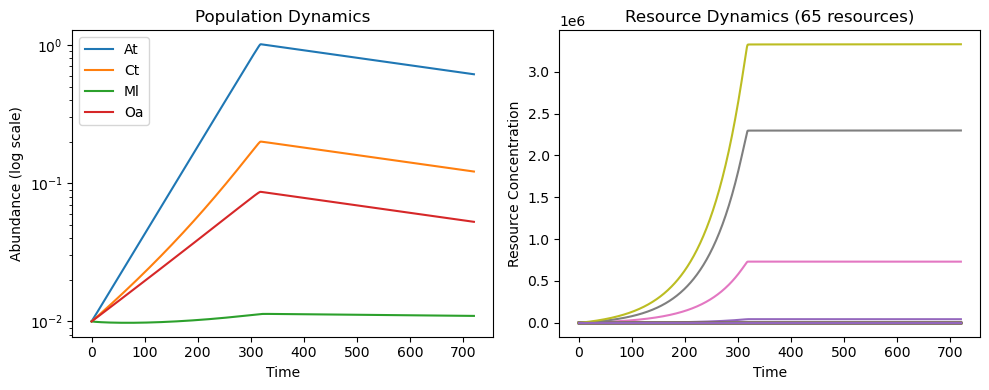

In [ ]:
# Example: Run CRM with trimmed matrices
# Initialize resources (only for active resources)
R0_trim = np.zeros(n_cs_trim)
R0_trim[0] = 15  # Set first active resource

# Create K matrix for trimmed system (in correct shape)
K_sim = np.random.lognormal(-3, 0.5, (n_cs_trim, 4))

# Create CRM instance with trimmed matrices
c_trim = CRM(4, n_cs_trim, 
             C=C_trim, 
             D=D_trim, 
             K=K_sim.T,  # Transpose to (n_species, n_resources)
             w=W_trim, 
             dilution_rate=0, 
             l=0.1, 
             g=1, 
             m=0.0125,
             atol=1e-10, 
             rtol=1e-8)

print(f"✓ CRM initialized with {n_cs_trim} active resources (reduced from {n_cs})")
print(f"  System size reduction: {100*(n_cs-n_cs_trim)/n_cs:.1f}%")
print()

# Run simulation with trimmed system
sol_trim = c_trim.run_log(72, N0.copy(), R0_trim.copy(), dt=0.1, method='LSODA', max_calls=1e5)

if sol_trim.success:
    print("✓ Integration succeeded with trimmed matrices")
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.semilogy(c_trim.N)
    plt.xlabel('Time')
    plt.ylabel('Abundance (log scale)')
    plt.title('Population Dynamics')
    plt.legend(['At', 'Ct', 'Ml', 'Oa'])
    
    plt.subplot(1, 2, 2)
    plt.plot(c_trim.R)
    plt.xlabel('Time')
    plt.ylabel('Resource Concentration')
    plt.title(f'Resource Dynamics ({n_cs_trim} resources)')
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Integration failed: {sol_trim.message}")

In [ ]:
# Optional: Inspect which resources were removed
removed_mask = ~trim_result['active_mask']
removed_indices = np.where(removed_mask)[0]

if len(removed_indices) > 0:
    print(f"Removed {len(removed_indices)} inactive resources:")
    print()
    
    # Show a sample of removed exchanges (if too many, show first 20)
    show_n = min(20, len(removed_indices))
    for i, idx in enumerate(removed_indices[:show_n]):
        ex_name = exchanges[idx]
        consumed_by = (C[:, idx] > 0).sum()
        produced_by = (D[:, :, idx].sum(axis=1) > 0).sum()
        print(f"  {i+1:3d}. {ex_name:30s} - consumed by {consumed_by}, produced by {produced_by}")
    
    if len(removed_indices) > show_n:
        print(f"  ... and {len(removed_indices) - show_n} more")
else:
    print("✓ All resources are active (none removed)")

Removed 97 inactive resources:

    1. R_EX_26dap__M_e                - consumed by 1, produced by 0
    2. R_EX_34dhbz_e                  - consumed by 2, produced by 0
    3. R_EX_3cmp_e                    - consumed by 2, produced by 0
    4. R_EX_3mb_e                     - consumed by 4, produced by 0
    5. R_EX_3oxoadp_e                 - consumed by 1, produced by 0
    6. R_EX_3ump_e                    - consumed by 1, produced by 0
    7. R_EX_4abut_e                   - consumed by 4, produced by 0
    8. R_EX_4hbz_e                    - consumed by 2, produced by 0
    9. R_EX_5aptn_e                   - consumed by 2, produced by 0
   10. R_EX_6hnac_e                   - consumed by 2, produced by 0
   11. R_EX_LalaDgluMdapDala_e        - consumed by 2, produced by 0
   12. R_EX_LalaLglu_e                - consumed by 4, produced by 0
   13. R_EX_acac_e                    - consumed by 1, produced by 0
   14. R_EX_ade_e                     - consumed by 2, produced by 0
  

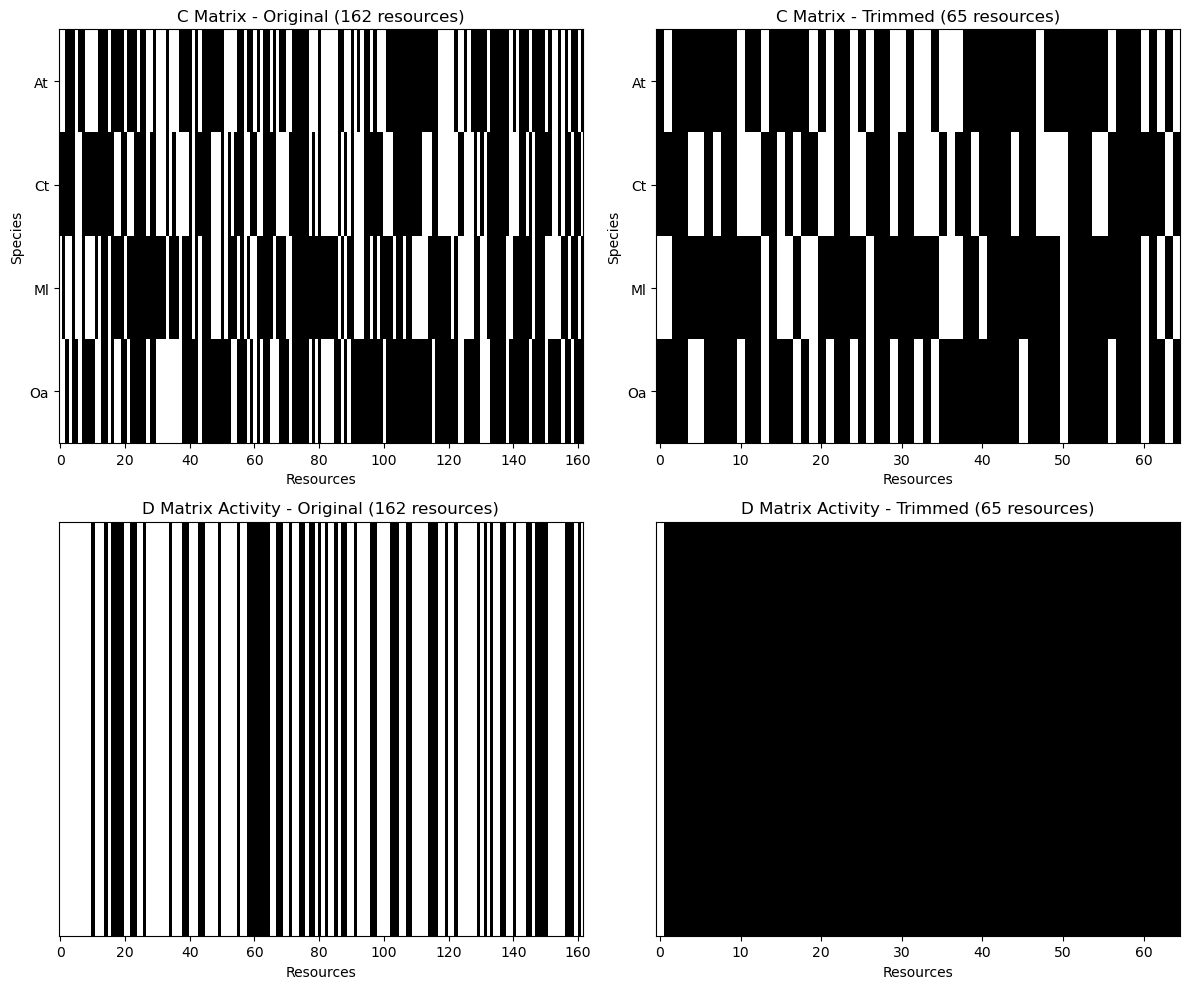

Matrix Statistics:
  Original - C zeros: 240/648 (37.0%)
  Trimmed  - C zeros: 78/260 (30.0%)
  Original - D zeros: 72776/104976 (69.3%)
  Trimmed  - D zeros: 4100/16900 (24.3%)


In [ ]:
# Visualize matrix sparsity comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original C matrix
ax = axes[0, 0]
im = ax.imshow(C > 0, aspect='auto', cmap='binary', interpolation='nearest')
ax.set_title(f'C Matrix - Original ({C.shape[1]} resources)')
ax.set_xlabel('Resources')
ax.set_ylabel('Species')
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['At', 'Ct', 'Ml', 'Oa'])

# Trimmed C matrix
ax = axes[0, 1]
im = ax.imshow(C_trim > 0, aspect='auto', cmap='binary', interpolation='nearest')
ax.set_title(f'C Matrix - Trimmed ({C_trim.shape[1]} resources)')
ax.set_xlabel('Resources')
ax.set_ylabel('Species')
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['At', 'Ct', 'Ml', 'Oa'])

# Original D sparsity (sum over species and source dimension)
ax = axes[1, 0]
D_viz = (D.sum(axis=(0, 1)) > 0).astype(float)
im = ax.imshow(D_viz.reshape(1, -1), aspect='auto', cmap='binary', interpolation='nearest')
ax.set_title(f'D Matrix Activity - Original ({D.shape[2]} resources)')
ax.set_xlabel('Resources')
ax.set_yticks([])

# Trimmed D sparsity
ax = axes[1, 1]
D_trim_viz = (D_trim.sum(axis=(0, 1)) > 0).astype(float)
im = ax.imshow(D_trim_viz.reshape(1, -1), aspect='auto', cmap='binary', interpolation='nearest')
ax.set_title(f'D Matrix Activity - Trimmed ({D_trim.shape[2]} resources)')
ax.set_xlabel('Resources')
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Print statistics
print("Matrix Statistics:")
print(f"  Original - C zeros: {(C==0).sum()}/{C.size} ({100*(C==0).sum()/C.size:.1f}%)")
print(f"  Trimmed  - C zeros: {(C_trim==0).sum()}/{C_trim.size} ({100*(C_trim==0).sum()/C_trim.size:.1f}%)")
print(f"  Original - D zeros: {(D==0).sum()}/{D.size} ({100*(D==0).sum()/D.size:.1f}%)")
print(f"  Trimmed  - D zeros: {(D_trim==0).sum()}/{D_trim.size} ({100*(D_trim==0).sum()/D_trim.size:.1f}%)")

In [ ]:
# Helper function to diagnose CRM parameter issues
def diagnose_crm_parameters(C, K, W, D, N0, R0):
    """Check CRM parameters for potential numerical issues."""
    print("=== CRM Parameter Diagnostics ===\n")
    
    # Check C matrix
    print(f"C (consumption rates):")
    print(f"  Range: [{C.min():.2e}, {C.max():.2e}]")
    print(f"  Zeros: {(C==0).sum()} / {C.size}")
    print(f"  Non-finite: {(~np.isfinite(C)).sum()}")
    print(f"  Scale ratio: {C.max()/max(C[C>0].min(), 1e-10):.2e}")
    
    # Check K matrix
    print(f"\nK (half-saturation):")
    print(f"  Range: [{K.min():.2e}, {K.max():.2e}]")
    print(f"  Scale ratio: {K.max()/max(K.min(), 1e-10):.2e}")
    if K.max()/K.min() > 1e6:
        print(f"  ⚠️  WARNING: Very wide K range - may cause stiffness")
    
    # Check W matrix
    print(f"\nW (energy content):")
    print(f"  Range: [{W.min():.2e}, {W.max():.2e}]")
    print(f"  Zeros: {(W==0).sum()} / {W.size}")
    
    # Check D matrix
    print(f"\nD (leakage matrix):")
    print(f"  Range: [{D.min():.2e}, {D.max():.2e}]")
    print(f"  Zeros: {(D==0).sum()} / {D.size} ({100*(D==0).sum()/D.size:.1f}%)")
    print(f"  NaNs: {np.isnan(D).sum()}")
    row_sums = D.sum(axis=2)
    print(f"  Row sums - Range: [{row_sums.min():.3f}, {row_sums.max():.3f}]")
    if not np.allclose(row_sums[row_sums>0], 1.0, atol=1e-3):
        print(f"  ⚠️  WARNING: D rows don't sum to 1")
    
    # Check initial conditions
    print(f"\nInitial conditions:")
    print(f"  N0 range: [{N0.min():.2e}, {N0.max():.2e}]")
    print(f"  R0 range: [{R0.min():.2e}, {R0.max():.2e}]")
    print(f"  R0 zeros: {(R0==0).sum()} / {len(R0)}")
    
    # Suggested improvements
    print(f"\n=== Recommendations ===")
    
    if K.max()/K.min() > 1e4:
        print("• Use a stiff solver: method='BDF' or 'Radau' or 'LSODA'")
    
    if (C==0).sum() > 0.5 * C.size:
        print("• Many zero C values - system may be sparse/slow")
    
    if (R0==0).sum() > 0.8 * len(R0):
        print("• Too many zero initial resources - try initializing more resources")
    
    if N0.max() / N0.min() > 100:
        print("• Wide range in initial abundances - may cause numerical issues")
    
    print("\nSuggested tolerances:")
    typical_N = np.median(N0)
    typical_R = np.median(R0[R0>0]) if np.any(R0>0) else 1.0
    print(f"  rtol = 1e-6 to 1e-8")
    print(f"  atol = {min(typical_N, typical_R)*1e-9:.2e}")

In [ ]:
# Run diagnostics before integration
diagnose_crm_parameters(C, K, W, D, N0, R0)

=== CRM Parameter Diagnostics ===

C (consumption rates):
  Range: [0.00e+00, 9.25e+01]
  Zeros: 240 / 648
  Non-finite: 0
  Scale ratio: 7.14e+02

K (half-saturation):
  Range: [1.00e-07, 4.82e+00]
  Scale ratio: 4.81e+07
  ⚠️  WARNING: Very wide K range - may cause stiffness

W (energy content):
  Range: [0.00e+00, 4.06e-01]
  Zeros: 4 / 162

D (leakage matrix):
  Range: [0.00e+00, 6.37e-01]
  Zeros: 72776 / 104976 (69.3%)
  NaNs: 0
  Row sums - Range: [1.000, 1.000]

Initial conditions:
  N0 range: [1.00e-02, 1.00e-02]
  R0 range: [0.00e+00, 1.50e+01]
  R0 zeros: 161 / 162

=== Recommendations ===
• Use a stiff solver: method='BDF' or 'Radau' or 'LSODA'
• Too many zero initial resources - try initializing more resources

Suggested tolerances:
  rtol = 1e-6 to 1e-8
  atol = 1.00e-11


## Improved Integration Strategy

**Key improvements made to CRM class:**

1. **Better initial condition handling** - Validates and clips non-finite values
2. **Numerical stability in ODE function** - Prevents negatives, clips extreme derivatives
3. **Robust Monod kinetics** - Safe division, handles edge cases
4. **Adaptive solver parameters** - Auto-adjusts step sizes and tolerances
5. **Better error reporting** - Shows what went wrong and how far it got

**Recommended solver settings by problem type:**

- **Stiff systems** (wide range of K values): `method='BDF'` or `'Radau'` or `'LSODA'`
- **Moderate systems**: `method='RK45'` (default)
- **High accuracy needed**: Use `rtol=1e-8, atol=1e-10`

**Try using:**
```python
c = CRM(4, n_cs, C=C, D=D, dilution_rate=1e-2, l=l, K=K.T, g=1, w=W, m=m, 
        rtol=1e-7, atol=1e-9)

# Use stiff solver for robustness
sol = c.run(72, N0, R0, dt=0.1, method='BDF', max_calls=1e5, adaptive_tolerance=True)
```

## Log-Transformed Integration

For systems where populations and resources span many orders of magnitude, **log-transformation** can dramatically improve numerical stability.

**How it works:**
- Instead of solving for N and R directly, we solve for log(N) and log(R)
- Transform: d(log y)/dt = (1/y) × dy/dt
- Benefits: uniform scale, better conditioning, prevents numerical underflow

**When to use log transformation:**
- ✅ Populations range from 10⁻⁸ to 10⁻² (or wider)
- ✅ Resources span multiple orders of magnitude  
- ✅ Getting numerical underflow errors
- ✅ Solver struggles with "stiffness"

**Usage:**
```python
# Instead of c.run(), use:
sol = c.run_log(72, N0, R0, dt=0.1, method='BDF', max_calls=1e5)
```

Log-transformation works with all solvers but pairs especially well with stiff solvers (BDF, Radau, LSODA).

✓ Log-transformed integration succeeded


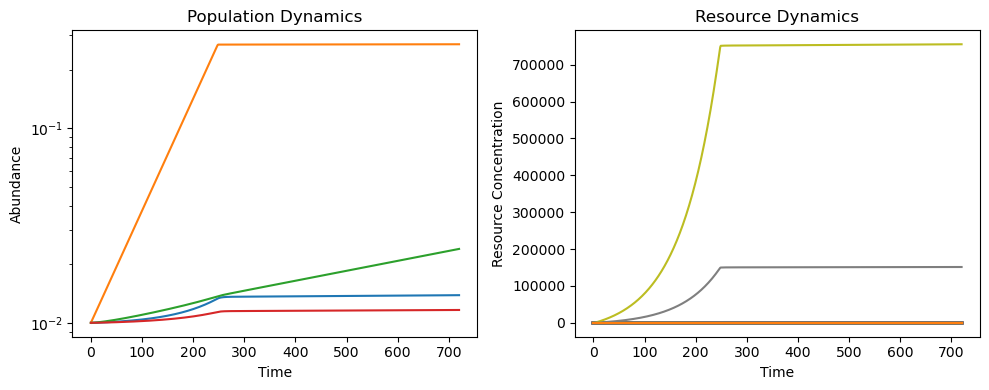

In [ ]:
# Example: Run with log transformation
K_log = np.random.lognormal(-3, 0.5, (n_cs, 4))
R0_log = np.zeros(n_cs)
R0_log[0] = 15

c_log = CRM(4, n_cs, C=C, D=D, dilution_rate=0, l=l, K=K_log.T, g=1, w=W, m=m, 
            atol=1e-10, rtol=1e-8)

# Use run_log instead of run for better numerical stability
sol_log = c_log.run_log(72, N0.copy(), R0_log.copy(), dt=0.1, method='BDF', 
                         max_calls=1e5, adaptive_tolerance=True)

if sol_log.success:
    print("✓ Log-transformed integration succeeded")
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.semilogy(c_log.N)
    plt.xlabel('Time')
    plt.ylabel('Abundance')
    plt.title('Population Dynamics')
    plt.subplot(1, 2, 2)
    plt.plot(c_log.R)
    plt.xlabel('Time')
    plt.ylabel('Resource Concentration')
    plt.title('Resource Dynamics')
    plt.tight_layout()
    plt.show()
else:
    print(f"Integration failed: {sol_log.message}")

In [ ]:
# Compare standard vs log-transformed integration
import time

# Test case: populations spanning many orders of magnitude
N0_test = np.array([1e-6, 1e-4, 1e-3, 1e-2])
R0_test = np.zeros(n_cs)
R0_test[0] = 10

c_test = CRM(4, n_cs, C=C, D=D, dilution_rate=0, l=l, K=K.T, g=1, w=W, m=m,
            atol=1e-9, rtol=1e-7)

print("=" * 60)
print("COMPARISON: Standard vs Log-transformed Integration")
print("=" * 60)

# Standard integration
print("\n1. Standard integration (run):")
t0 = time.time()
sol_std = c_test.run(50, N0_test.copy(), R0_test.copy(), dt=0.1, method='BDF', max_calls=1e5)
t_std = time.time() - t0
print(f"   Time: {t_std:.3f}s | Success: {sol_std.success} | Steps: {len(sol_std.t)}")
if sol_std.success:
    print(f"   Final abundances: {c_test.N[-1, :]}")

# Log-transformed integration  
print("\n2. Log-transformed integration (run_log):")
t0 = time.time()
sol_log = c_test.run_log(50, N0_test.copy(), R0_test.copy(), dt=0.1, method='BDF', max_calls=1e5)
t_log = time.time() - t0
print(f"   Time: {t_log:.3f}s | Success: {sol_log.success} | Steps: {len(sol_log.t)}")
if sol_log.success:
    print(f"   Final abundances: {c_test.N[-1, :]}")

print("\n" + "=" * 60)
if sol_std.success and sol_log.success:
    speedup = t_std / t_log
    print(f"Speedup: {speedup:.2f}x {'(log faster)' if speedup > 1 else '(standard faster)'}")
elif sol_log.success and not sol_std.success:
    print("✓ Log-transformed succeeded where standard failed!")
elif sol_std.success and not sol_log.success:
    print("Standard succeeded where log-transformed failed")
else:
    print("Both methods failed - check parameters")

AssertionError: 

### Quick Decision Guide: Which Integration Method?

| Situation | Recommended Method | Solver |
|-----------|-------------------|--------|
| Populations: 10⁻² to 10⁻¹ | `run()` | RK45 or LSODA |
| Populations: 10⁻⁶ to 10⁻² | `run_log()` | BDF or LSODA |
| Wide K range (>10⁴) | `run_log()` | BDF |
| Numerical underflow errors | `run_log()` | BDF |
| Fast & stable | `run()` | RK45 |
| Maximum robustness | `run_log()` | BDF |

**Key differences:**
- `run()`: Standard integration, faster but less stable for extreme ranges
- `run_log()`: Log-transformed, more stable but slightly slower
- `run_step()`: Manual stepping, most control but slowest

**Your current system diagnosis shows:**
Run the diagnostics cell above to see which method is best for your parameters!

In [ ]:
sol.t

array([0.00000000e+00, 1.84504791e-06, 3.69009583e-06, 7.38019166e-06,
       1.10702875e-05, 1.47603833e-05, 4.77769276e-05, 8.07934718e-05,
       1.13810016e-04, 1.46826560e-04, 2.95612388e-04, 4.44398216e-04,
       5.93184044e-04, 7.41969872e-04, 8.90755700e-04, 1.12584565e-03,
       1.36093561e-03, 1.59602556e-03, 1.83111551e-03, 2.06620547e-03,
       2.30129542e-03, 2.69020375e-03, 3.07911208e-03, 3.46802042e-03,
       3.85692875e-03, 4.24583708e-03, 4.63474541e-03, 5.02365374e-03,
       5.39985657e-03, 5.77605940e-03, 6.15226222e-03, 6.52846505e-03,
       6.90466788e-03, 7.28087071e-03, 7.65707353e-03, 8.13446131e-03,
       8.61184908e-03, 9.08923685e-03, 9.56662462e-03, 1.00440124e-02,
       1.05214002e-02, 1.09987879e-02, 1.14761757e-02, 1.19535635e-02,
       1.25689363e-02, 1.31843090e-02, 1.37996818e-02, 1.44150546e-02,
       1.50304273e-02, 1.57509265e-02, 1.64714257e-02, 1.71919249e-02,
       1.79124241e-02, 1.86136152e-02, 1.93148063e-02, 2.00159974e-02,
      

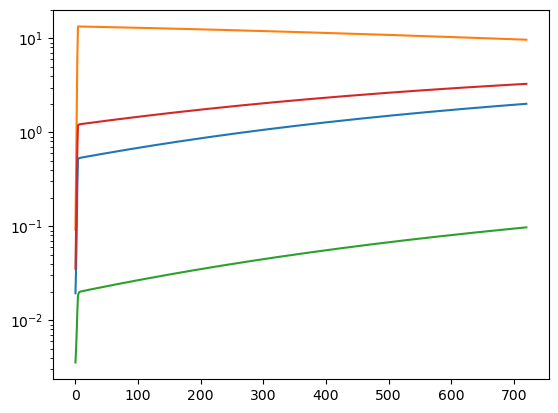

In [ ]:
plt.semilogy(c.N)

In [ ]:
model_data['exchanges']

KeyError: 'exchanges'

In [ ]:
[i for i, x in enumerate(model_data['exchanges']) if x ==  'R_EX_glc__D_e']

[]